<a href="https://colab.research.google.com/github/sergiodanier1/acuacode/blob/main/IA_pokemon_generativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conectar con el drive



In [24]:
import os
import shutil

# 1. Mover cualquier contenido existente en /content/drive a una carpeta de respaldo
if os.path.exists("/content/drive"):
    backup_dir = "/content/drive_backup"
    os.makedirs(backup_dir, exist_ok=True)
    for item in os.listdir("/content/drive"):
        src = os.path.join("/content/drive", item)
        dst = os.path.join(backup_dir, item)
        shutil.move(src, dst)
        print(f"Movido: {src} → {dst}")
    print("✅ Contenido movido a /content/drive_backup")
else:
    print("El directorio /content/drive no existe, se creará al montar.")

Movido: /content/drive/MyDrive → /content/drive_backup/MyDrive
✅ Contenido movido a /content/drive_backup


In [25]:
import os
import shutil
from google.colab import drive

def montar_drive():
    """Monta Google Drive en /content/drive sin errores, moviendo archivos si es necesario."""
    mount_point = "/content/drive"
    drive_path = os.path.join(mount_point, "MyDrive")

    # 1. Verificar si ya está montado
    if os.path.exists(drive_path):
        print("✅ Drive ya está montado en /content/drive")
        return

    # 2. Si no está montado, ver si el directorio contiene archivos
    if os.path.exists(mount_point):
        contenido = os.listdir(mount_point)
        if contenido:
            print(f"⚠️ El directorio {mount_point} contiene: {contenido}")
            print("Moviendo a respaldo temporal...")
            backup = "/content/drive_backup"
            os.makedirs(backup, exist_ok=True)
            # Mover todo a respaldo
            for item in contenido:
                shutil.move(os.path.join(mount_point, item), os.path.join(backup, item))
            print("✅ Contenido movido a", backup)

    # 3. Montar Drive (ahora el directorio está vacío)
    print("Montando Google Drive...")
    drive.mount(mount_point, force_remount=True)

    # 4. Restaurar los archivos respaldados dentro del Drive montado
    if os.path.exists("/content/drive_backup"):
        print("Restaurando archivos respaldados...")
        for item in os.listdir("/content/drive_backup"):
            shutil.move(
                os.path.join("/content/drive_backup", item),
                os.path.join(mount_point, item)
            )
        # Eliminar la carpeta de respaldo vacía
        os.rmdir("/content/drive_backup")
        print("✅ Archivos restaurados dentro de /content/drive")

    print("✅ Drive montado exitosamente en /content/drive")

# Ejecutar
montar_drive()

# Verificar que está montado
print("Contenido de /content/drive/MyDrive:")
print(os.listdir("/content/drive/MyDrive"))

Montando Google Drive...
Mounted at /content/drive
Restaurando archivos respaldados...
✅ Archivos restaurados dentro de /content/drive
✅ Drive montado exitosamente en /content/drive
Contenido de /content/drive/MyDrive:
['Sergio klei_1.jpg', 'IMG_20250212_145102.jpg', 'FB_IMG_1739390176419.jpg', 'IMG_20250212_144624.jpg', 'Screenshot_2025-02-07-15-36-30-536_com.nequi.MobileApp.jpg', 'IMG_20250210_113221_1.jpg', 'IMG_20250212_144615_1.jpg', 'IMG_20250212_144525_1.jpg', 'IMG_20250212_144545_1.jpg', 'Sergio klei_2.jpg', 'IMG_20250210_114347_1.jpg', 'FB_IMG_1739204030647.jpg', 'sergio (1).jpg', 'IMG-20140516-WA0000.jpg', 'escritura.docx', 'escritura (1).docx.gdoc', 'escritura.docx.gdoc', 'sergio.rar', '3089709.m4a', 'estamosciegosjurgenklaric-reddiamantes-ivoox1902604.mp3', 'NEGOCIACION.pptx', 'Parche.psd', 'Reflejo.psd', 'PHOTO', 'SITIO PRUEBA.rar', 'PAG32 (1).rar', 'Manzana.pdf.gdoc', 'Potos', 'justificacion_faltas_tardanzas.doc', 'ENCUESTA.xlsx', 'INFORME DE IMAGEN CORPORATIVA.docx', 'pl

Dependencias

In [21]:
!pip install tqdm matplotlib pillow pandas numpy torch torchvision -q
!pip install -q tensorflow pandas scikit-learn

2. Cargar librerías

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split



3 Rutas

In [26]:
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")
ARCHIVO_CSV = os.path.join(
    BASE_DIR,
    "metadata",
    "etiquetas_pokemon.csv"
)
#Leer el csv
metadata = pd.read_csv(ARCHIVO_CSV)
metadata.head()

,nombre_archivo,postura_bipedo,postura_cuadrupedo,postura_serpentiforme,postura_volador,ojos_circulares,ojos_rasgados,sin_ojos,delantera_brazo,delantera_pata,delantera_ala,sin_delantera,trasera_pata_animal,trasera_pata_ave,sin_trasera,cola_larga_flexible,cola_maza,sin_cola,nivel_evolutivo
0,001.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1
1,002.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,2
2,003.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,3
3,004.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1
4,005.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,2


5. cargar imagenes

In [27]:
#cargar imagenes
archivos = sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))
imagenes = []
for archivo in archivos:
    img = np.load(archivo)
    img = img.astype(np.float32)
    if img.max()>1:
        img = img/255.0
    imagenes.append(img)
imagenes = np.array(imagenes)
print(imagenes.shape)

(3075, 64, 64, 3)


6. División entrenamiento

In [28]:
#Division de entrenamiento
x_train, x_test = train_test_split(
    imagenes,
    test_size=0.1,
    random_state=42
)
#dimensiones
alto = imagenes.shape[1]
ancho = imagenes.shape[2]
canales = imagenes.shape[3]

latent_dim = 128
#Encoder
encoder_inputs = tf.keras.Input(shape=(alto,ancho,canales))
x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)
shape_before = tf.keras.backend.int_shape(x)
x = layers.Flatten()(x)
z = layers.Dense(latent_dim)(x)
encoder = tf.keras.Model(encoder_inputs,z)
encoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,952 (4.36 MB)

 Trainable params: 1,141,952 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

9. Decoder

In [29]:
#Decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
unidades = int(np.prod(shape_before[1:]))
x = layers.Dense(unidades)(decoder_inputs)
x = layers.Reshape(shape_before[1:])(x)

x = layers.Conv2DTranspose(
    128,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = layers.Conv2D(
    canales,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = tf.keras.Model(decoder_inputs, decoder_outputs)

10. Autoencoder

In [30]:
inputs = tf.keras.Input(shape=(alto,ancho,canales))

latent = encoder(inputs)

outputs = decoder(latent)

autoencoder = tf.keras.Model(inputs,outputs)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

11. Entrenamiento

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Carpeta donde se guardarán las imágenes de cada época
CARPETA_RESULTADOS = os.path.join(BASE_DIR, "imagenes_entrenamiento")
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)
class GuardarImagenes(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Generar 9 imágenes aleatorias
        ruido = np.random.normal(size=(9, latent_dim))
        imagenes = decoder.predict(ruido, verbose=0)
        fig, axs = plt.subplots(3, 3, figsize=(6,6))
        for i, ax in enumerate(axs.flat):
            ax.imshow(np.clip(imagenes[i],0,1))
            ax.axis("off")
        plt.tight_layout()
        nombre = os.path.join(
            CARPETA_RESULTADOS,
            f"epoch_{epoch+1:03d}.png"
        )
        plt.savefig(nombre)
        plt.close(fig)
        print(f"\nImagen guardada: {nombre}")
# Entrenamiento
history = autoencoder.fit(
    x_train,
    x_train,
    validation_data=(x_test, x_test),
    epochs=200,
    batch_size=32,
    callbacks=[GuardarImagenes()]
)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - loss: 0.6433
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_001.png
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 661ms/step - loss: 0.5640 - val_loss: 0.4496
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - loss: 0.4301
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_002.png
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 602ms/step - loss: 0.4270 - val_loss: 0.4386
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - loss: 0.4161
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_003.png
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 635ms/step - loss: 0.4170 - val_loss: 0.4095
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - loss: 0.3729
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_004.png
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 625ms/step - loss: 0.3645 - val_loss: 0.3355
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━

12. Guardar modelo

In [ ]:
MODELOS = os.path.join(BASE_DIR,"modelos")

os.makedirs(MODELOS,exist_ok=True)

autoencoder.save(
    os.path.join(MODELOS,"pokemon_generator.keras")
)

13. Generar nuevos Pokémon

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


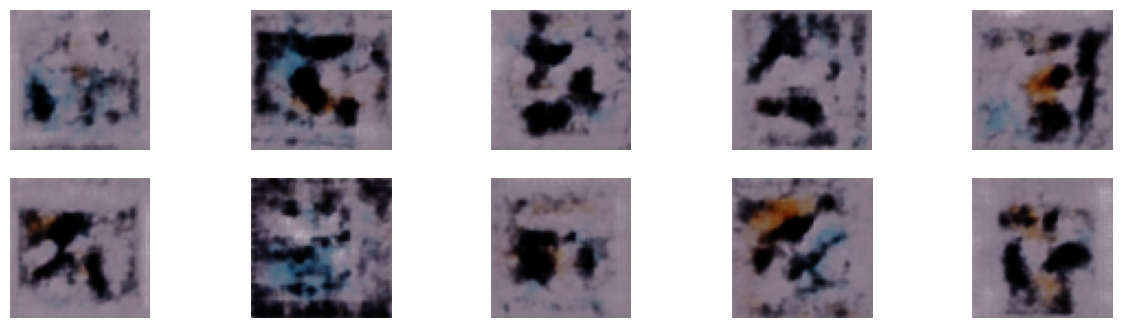

In [ ]:
import matplotlib.pyplot as plt

ruido = np.random.normal(
    size=(10,latent_dim)
)

imagenes_generadas = decoder.predict(ruido)

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(imagenes_generadas[i])

    plt.axis("off")

plt.show()

Modelo Gan

In [ ]:
import os, glob, csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ================= CONFIG =================
BASE_DIR="/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES=os.path.join(BASE_DIR,"datos_procesados")
NUM_IMAGENES=1025
IMG_SIZE=64
CHANNELS=3
LATENT_DIM=256
EPOCHS=250
BATCH_SIZE=32
LR_G = 2e-4
LR_D = 1e-4
LR=2e-4
BETA1=0.5
GUARDAR_CADA=5

OUT=os.path.join(BASE_DIR,"GAN")
IMG_DIR=os.path.join(OUT,"imagenes_entrenamiento2")
MODEL_DIR=os.path.join(OUT,"modelos")
os.makedirs(IMG_DIR,exist_ok=True)
os.makedirs(MODEL_DIR,exist_ok=True)

# ================ DATA ====================
files=sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))
if NUM_IMAGENES:
    files=files[:NUM_IMAGENES]

imgs=[]
for f in files:
    x=np.load(f).astype("float32")
    if x.max()>1: x/=255.
    if x.shape[:2]!=(IMG_SIZE,IMG_SIZE):
        x=tf.image.resize(x,(IMG_SIZE,IMG_SIZE)).numpy()
    imgs.append(x)
imgs=np.array(imgs)
dataset=tf.data.Dataset.from_tensor_slices(imgs).shuffle(len(imgs)).batch(BATCH_SIZE)

# ============== MODELS ====================
def build_generator():
    z=tf.keras.Input((LATENT_DIM,))
    x=layers.Dense(8*8*256,use_bias=False)(z)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU()(x)
    x=layers.Reshape((8,8,256))(x)
    for f in [128,64,32]:
        x=layers.Conv2DTranspose(f,4,2,"same",use_bias=False)(x)
        x=layers.BatchNormalization()(x)
        x=layers.LeakyReLU()(x)
    out=layers.Conv2D(CHANNELS,3,padding="same",activation="sigmoid")(x)
    return tf.keras.Model(z,out)

def build_discriminator():
    i=tf.keras.Input((IMG_SIZE,IMG_SIZE,CHANNELS))
    x=i
    for f in [32,64,128]:
        x=layers.Conv2D(f,4,2,"same")(x)
        x=layers.LeakyReLU(0.2)(x)
        x=layers.Dropout(.3)(x)
    x=layers.Flatten()(x)
    out=layers.Dense(1)(x)
    return tf.keras.Model(i,out)

G=build_generator()
D=build_discriminator()

bce=tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_opt=tf.keras.optimizers.Adam(LR_G,beta_1=BETA1)
d_opt=tf.keras.optimizers.Adam(LR_D,beta_1=BETA1)

@tf.function
def train_step(real):
    noise=tf.random.normal([tf.shape(real)[0],LATENT_DIM])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake=G(noise,training=True)
        r=D(real,training=True)
        f=D(fake,training=True)
        g_loss=bce(tf.ones_like(f),f)
        d_loss=bce(tf.ones_like(r),r)+bce(tf.zeros_like(f),f)
    g_opt.apply_gradients(zip(gt.gradient(g_loss,G.trainable_variables),G.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss,D.trainable_variables),D.trainable_variables))
    return g_loss,d_loss

fixed=tf.random.normal([9,LATENT_DIM])
hist=os.path.join(OUT,"historial.csv")
with open(hist,"w",newline="") as f:
    w=csv.writer(f); w.writerow(["epoch","g_loss","d_loss"])
    for e in range(EPOCHS):
        gl=dl=0
        n=0
        for batch in dataset:
            g,d=train_step(batch)
            gl+=float(g); dl+=float(d); n+=1
        gl/=n; dl/=n
        print(f"Epoch {e+1}/{EPOCHS} G={gl:.4f} D={dl:.4f}")
        w.writerow([e+1,gl,dl]); f.flush()
        if (e+1)%GUARDAR_CADA==0:
            samples=G(fixed,training=False).numpy()
            fig,ax=plt.subplots(3,3,figsize=(6,6))
            for i,a in enumerate(ax.flat):
                a.imshow(np.clip(samples[i],0,1)); a.axis("off")
            plt.tight_layout()
            plt.savefig(os.path.join(IMG_DIR,f"epoch_{e+1:03d}.png"))
            plt.close(fig)
            G.save(os.path.join(MODEL_DIR,f"generador_epoch_{e+1:03d}.keras"))
            D.save(os.path.join(MODEL_DIR,f"discriminador_epoch_{e+1:03d}.keras"))

G.save(os.path.join(MODEL_DIR,"generador_final.keras"))
D.save(os.path.join(MODEL_DIR,"discriminador_final.keras"))
print("Entrenamiento finalizado.")


KeyboardInterrupt: 

correcion del GAN

In [ ]:
import os, glob, csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ================= CONFIG =================
BASE_DIR="/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES=os.path.join(BASE_DIR,"datos_procesados")
NUM_IMAGENES= None
IMG_SIZE=64
CHANNELS=3
LATENT_DIM=256
EPOCHS=500
BATCH_SIZE=32
LR_G = 2e-4
LR_D = 1e-4
LR=2e-4
BETA1=0.5
GUARDAR_CADA=10

OUT=os.path.join(BASE_DIR,"GAN")
IMG_DIR=os.path.join(OUT,"imagenes_entrenamiento2")
MODEL_DIR=os.path.join(OUT,"modelos")
os.makedirs(IMG_DIR,exist_ok=True)
os.makedirs(MODEL_DIR,exist_ok=True)

# ================ DATA ====================
files=sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))
if NUM_IMAGENES:
    files=files[:NUM_IMAGENES]
print(f"Imágenes cargadas: {len(files)}")

imgs=[]
for f in files:
    x=np.load(f).astype("float32")
    if x.max()>1: x/=255.
    if x.shape[:2]!=(IMG_SIZE,IMG_SIZE):
        x=tf.image.resize(x,(IMG_SIZE,IMG_SIZE)).numpy()
    imgs.append(x)
imgs=np.array(imgs)
dataset = (
    tf.data.Dataset.from_tensor_slices(imgs)
    .shuffle(len(imgs))
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

# ============== MODELS ====================
def build_generator():
    z = tf.keras.Input(shape=(LATENT_DIM,))
    x = layers.Dense(8 * 8 * 256, use_bias=False)(z)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((8, 8, 256))(x)
    for filtros in [128, 64, 32]:
        x = layers.Conv2DTranspose(
            filtros,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    salida = layers.Conv2D(
        CHANNELS,
        kernel_size=3,
        padding="same",
        activation="tanh"
    )(x)
    return tf.keras.Model(z, salida)

def build_discriminator():
    entrada = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    x = layers.GaussianNoise(0.05)(entrada)
    for filtros in [32, 64, 128, 256]:
        x = layers.Conv2D(
            filtros,
            kernel_size=4,
            strides=2,
            padding="same"
        )(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    salida = layers.Dense(1)(x)
    return tf.keras.Model(entrada, salida, name="Discriminator")

G=build_generator()
D=build_discriminator()

bce=tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_opt=tf.keras.optimizers.Adam(LR_G,beta_1=BETA1)
d_opt=tf.keras.optimizers.Adam(LR_D,beta_1=BETA1)

@tf.function

def train_step(real):
    batch = tf.shape(real)[0]
    noise = tf.random.normal([batch, LATENT_DIM])
    real_labels = tf.random.uniform(
      (batch, 1),
      minval=0.8,
      maxval=1.0
    )

    fake_labels = tf.random.uniform(
      (batch, 1),
      minval=0.0,
      maxval=0.2
    )
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        # Generar imágenes falsas
        fake = G(noise, training=True)
        # <<< AGREGA ESTAS DOS LÍNEAS AQUÍ >>>
        fake += tf.random.normal(tf.shape(fake), stddev=0.01)
        fake = tf.clip_by_value(fake, -1.0, 1.0)
        # Discriminador
        real_out = D(real, training=True)
        fake_out = D(fake, training=True)
        # Pérdidas
        g_loss = bce(tf.ones_like(fake_out), fake_out)
        d_real = bce(real_labels, real_out)
        d_fake = bce(fake_labels, fake_out)
        d_loss = d_real + d_fake
    g_grad = gt.gradient(g_loss, G.trainable_variables)
    d_grad = dt.gradient(d_loss, D.trainable_variables)
    g_opt.apply_gradients(zip(g_grad, G.trainable_variables))
    d_opt.apply_gradients(zip(d_grad, D.trainable_variables))
    return g_loss, d_loss

fixed=tf.random.normal([9,LATENT_DIM])
hist=os.path.join(OUT,"historial.csv")
with open(hist,"w",newline="") as f:
    w=csv.writer(f); w.writerow(["epoch","g_loss","d_loss"])
    for e in range(EPOCHS):
        gl=dl=0
        n=0
        for batch in dataset:
            g,d=train_step(batch)
            gl+=float(g); dl+=float(d); n+=1
        gl/=n; dl/=n
        print(f"Epoch {e+1}/{EPOCHS} G={gl:.4f} D={dl:.4f}")
        w.writerow([e+1,gl,dl]); f.flush()
        if (e+1)%GUARDAR_CADA==0:
            samples = G(fixed, training=False).numpy()
        # Convertir de [-1,1] a [0,1]
            samples = (samples + 1.0) / 2.0
            samples = np.clip(samples, 0, 1)
            fig, ax = plt.subplots(3,3,figsize=(6,6))
            for i,a in enumerate(ax.flat):
              a.imshow(samples[i])
              a.axis("off")
            plt.tight_layout()
            plt.savefig(os.path.join(IMG_DIR,f"epoch_{e+1:03d}.png"))
            plt.close(fig)
            G.save(os.path.join(MODEL_DIR,f"generador_epoch_{e+1:03d}.keras"))
            D.save(os.path.join(MODEL_DIR,f"discriminador_epoch_{e+1:03d}.keras"))

G.save(os.path.join(MODEL_DIR,"generador_final.keras"))
D.save(os.path.join(MODEL_DIR,"discriminador_final.keras"))
print("Entrenamiento finalizado.")

Imágenes cargadas: 3075
Epoch 1/500 G=0.9466 D=1.1203
Epoch 2/500 G=0.7118 D=1.3702
Epoch 3/500 G=0.7408 D=1.3395
Epoch 4/500 G=0.7171 D=1.3646
Epoch 5/500 G=0.6925 D=1.3828
Epoch 6/500 G=0.6918 D=1.3856
Epoch 7/500 G=0.6924 D=1.3850
Epoch 8/500 G=0.7001 D=1.3769
Epoch 9/500 G=0.7025 D=1.3730
Epoch 10/500 G=0.7204 D=1.3562
Epoch 11/500 G=0.7336 D=1.3593
Epoch 12/500 G=0.7187 D=1.3641
Epoch 13/500 G=0.7065 D=1.3705
Epoch 14/500 G=0.7037 D=1.3657
Epoch 15/500 G=0.7136 D=1.3658
Epoch 16/500 G=0.7122 D=1.3670
Epoch 17/500 G=0.7183 D=1.3592
Epoch 18/500 G=0.7325 D=1.3516
Epoch 19/500 G=0.7324 D=1.3572
Epoch 20/500 G=0.7400 D=1.3382
Epoch 21/500 G=0.7569 D=1.3387
Epoch 22/500 G=0.7638 D=1.3128
Epoch 23/500 G=0.7637 D=1.3400
Epoch 24/500 G=0.7429 D=1.3426
Epoch 25/500 G=0.7561 D=1.3333
Epoch 26/500 G=0.7464 D=1.3340
Epoch 27/500 G=0.7590 D=1.3319
Epoch 28/500 G=0.7447 D=1.3370
Epoch 29/500 G=0.7549 D=1.3369
Epoch 30/500 G=0.7552 D=1.3392
Epoch 31/500 G=0.7544 D=1.3363
Epoch 32/500 G=0.7507 D=

codigo optimizado 1

In [ ]:
import os
import glob
import csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
# ================= CONFIG =================
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")
NUM_IMAGENES = None  # Opcional: limitar número de imágenes
IMG_SIZE = 64
CHANNELS = 3
LATENT_DIM = 256
EPOCHS = 500
BATCH_SIZE = 32
LR_G = 2e-4
LR_D = 1e-4
BETA1 = 0.5
GUARDAR_CADA = 5

OUT = os.path.join(BASE_DIR, "GAN")
IMG_DIR = os.path.join(OUT, "imagenes_entrenamiento2")
MODEL_DIR = os.path.join(OUT, "modelos")
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
# ================ OPTIMIZACIONES ============
# 1. Mixed Precision (float16)
tf.keras.mixed_precision.set_global_policy('mixed_float16')
# 2. XLA (compilación acelerada)
tf.config.optimizer.set_jit(True)
print("Política de precisión:", tf.keras.mixed_precision.global_policy())
print("XLA habilitado:", tf.config.optimizer.get_jit())
# ================ DATA ====================
files = sorted(glob.glob(os.path.join(CARPETA_IMAGENES, "*.npy")))
if NUM_IMAGENES:
    files = files[:NUM_IMAGENES]
print(f"Imágenes cargadas: {len(files)}")

if not files:
    raise ValueError("No se encontraron archivos .npy en la carpeta.")

imgs = []
for f in files:
    x = np.load(f).astype("float32")
    if x.max() > 1.0:
        x /= 255.0
    if x.shape[:2] != (IMG_SIZE, IMG_SIZE):
        x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE)).numpy()
    imgs.append(x)
imgs = np.array(imgs)
print(f"Shape del dataset: {imgs.shape}")

dataset = (
    tf.data.Dataset.from_tensor_slices(imgs)
    .shuffle(len(imgs))
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

# ============== MODELOS ====================
def build_generator():
    z = tf.keras.Input(shape=(LATENT_DIM,))
    x = layers.Dense(8 * 8 * 256, use_bias=False)(z)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((8, 8, 256))(x)
    for filtros in [128, 64, 32]:
        x = layers.Conv2DTranspose(
            filtros,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    salida = layers.Conv2D(
        CHANNELS,
        kernel_size=3,
        padding="same",
        activation="tanh"
    )(x)
    return tf.keras.Model(z, salida)

def build_discriminator():
    entrada = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    x = layers.GaussianNoise(0.05)(entrada)
    for filtros in [32, 64, 128, 256]:
        x = layers.Conv2D(
            filtros,
            kernel_size=4,
            strides=2,
            padding="same"
        )(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    salida = layers.Dense(1)(x)
    return tf.keras.Model(entrada, salida, name="Discriminator")

G = build_generator()
D = build_discriminator()

# ============== OPTIMIZADORES ============
# Optimizadores base
g_opt_base = tf.keras.optimizers.Adam(LR_G, beta_1=BETA1)
d_opt_base = tf.keras.optimizers.Adam(LR_D, beta_1=BETA1)

# Envuelta para mixed precision
g_opt = tf.keras.mixed_precision.LossScaleOptimizer(g_opt_base)
d_opt = tf.keras.mixed_precision.LossScaleOptimizer(d_opt_base)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# ============== FUNCIÓN DE ENTRENAMIENTO ============
@tf.function
def train_step(real):
    batch = tf.shape(real)[0]
    noise = tf.random.normal([batch, LATENT_DIM])

    real_labels = tf.random.uniform((batch, 1), minval=0.8, maxval=1.0)
    fake_labels = tf.random.uniform((batch, 1), minval=0.0, maxval=0.2)

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = G(noise, training=True)
        fake += tf.random.normal(tf.shape(fake), stddev=0.01)
        fake = tf.clip_by_value(fake, -1.0, 1.0)

        real_out = D(real, training=True)
        fake_out = D(fake, training=True)

        g_loss = bce(tf.ones_like(fake_out), fake_out)
        d_real = bce(real_labels, real_out)
        d_fake = bce(fake_labels, fake_out)
        d_loss = d_real + d_fake

    # Escalar pérdidas para mixed precision
    scaled_g_loss = g_opt.get_scaled_loss(g_loss)
    g_grad = gt.gradient(scaled_g_loss, G.trainable_variables)
    g_grad = g_opt.get_unscaled_gradients(g_grad)
    g_opt.apply_gradients(zip(g_grad, G.trainable_variables))

    scaled_d_loss = d_opt.get_scaled_loss(d_loss)
    d_grad = dt.gradient(scaled_d_loss, D.trainable_variables)
    d_grad = d_opt.get_unscaled_gradients(d_grad)
    d_opt.apply_gradients(zip(d_grad, D.trainable_variables))

    return g_loss, d_loss

# ============== CHECKPOINT PARA REANUDAR ============
epoch_var = tf.Variable(0, dtype=tf.int64)

checkpoint = tf.train.Checkpoint(
    generator=G,
    discriminator=D,
    g_optimizer=g_opt,
    d_optimizer=d_opt,
    epoch=epoch_var
)

manager = tf.train.CheckpointManager(
    checkpoint,
    directory=MODEL_DIR,
    max_to_keep=3  # guarda los últimos 3 checkpoints
)

# Intentar restaurar el último checkpoint
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint)
    inicio = int(epoch_var.numpy())
    print(f"Checkpoint restaurado. Reanudando desde época {inicio+1}")
else:
    inicio = 0
    print("No se encontró checkpoint. Comenzando desde cero.")

# ============== BUCLE DE ENTRENAMIENTO ============
fixed = tf.random.normal([9, LATENT_DIM])
hist_path = os.path.join(OUT, "historial.csv")

# Si existe historial, abrir en modo append; si no, crear con cabecera
write_header = not os.path.exists(hist_path)
f_hist = open(hist_path, "a", newline="")
w = csv.writer(f_hist)
if write_header:
    w.writerow(["epoch", "g_loss", "d_loss"])

for e in range(inicio, EPOCHS):
    gl = 0.0
    dl = 0.0
    n = 0
    for batch in dataset:
        g, d = train_step(batch)
        gl += float(g)
        dl += float(d)
        n += 1
    gl /= n
    dl /= n
    print(f"Epoch {e+1}/{EPOCHS} G={gl:.4f} D={dl:.4f}")

    # Guardar en historial
    w.writerow([e+1, gl, dl])
    f_hist.flush()

    # Actualizar variable de época
    epoch_var.assign(e + 1)

    # Cada GUARDAR_CADA épocas: guardar checkpoint, imágenes y modelos .keras
    if (e + 1) % GUARDAR_CADA == 0:
        manager.save()

        # Generar y guardar imagen de muestra
        samples = G(fixed, training=False).numpy()
        samples = (samples + 1.0) / 2.0
        samples = np.clip(samples, 0, 1)
        fig, ax = plt.subplots(3, 3, figsize=(6, 6))
        for i, a in enumerate(ax.flat):
            a.imshow(samples[i])
            a.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(IMG_DIR, f"epoch_{e+1:03d}.png"))
        plt.close(fig)

        # Guardar modelos en .keras (opcional, pero útil)
        G.save(os.path.join(MODEL_DIR, f"generador_epoch_{e+1:03d}.keras"))
        D.save(os.path.join(MODEL_DIR, f"discriminador_epoch_{e+1:03d}.keras"))

# Guardar final
manager.save()
G.save(os.path.join(MODEL_DIR, "generador_final.keras"))
D.save(os.path.join(MODEL_DIR, "discriminador_final.keras"))
f_hist.close()

print("Entrenamiento finalizado.")